In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Fetch SQL Files/feature eengineeering for ML segemantation.csv")

In [ ]:
df.head(40)

,customer_id,order_id,order_date,recency_days,total_spend,avg_installments,max_installments,payment_count,review_score,review_available_flag,review_count,returns_count,total_refund_amount,return_flag,refund_to_spend_ratio,device_type,acquisition_channel,lifecycle_stage,customer_city,customer_state
0,08c5351a6aca1c1589a38f244edeee9d,2e7a8482f6fb09756ca50c10d7bfc047,2016-09-04,773,136.23,1.0,1,1,1.0,1,1,0,0.0,0,0.0,Desktop,Email,Churned,boa vista,RR
1,683c54fc24d40ee9f8a6fc179fd9856c,e5fa5a7210941f7d56d0208e4e071d35,2016-09-05,772,75.06,3.0,3,1,1.0,1,1,0,0.0,0,0.0,App,Direct,Churned,passo fundo,RS
2,622e13439d6b5a0b486c435618b2679e,809a282bbd5dbcabb6f2f724fca862ec,2016-09-13,764,40.95,2.0,2,1,1.0,1,1,0,0.0,0,0.0,Mobile,Paid Search,Churned,sao jose dos campos,SP
3,86dc2ffce2dfff336de2f386a786e574,bfbd0f9bdef84302105ad712db648a6c,2016-09-15,762,0.00,0.0,0,0,1.0,1,1,0,0.0,0,NaN,Mobile,Paid Search,Churned,sao joaquim da barra,SP
4,b106b360fe2ef8849fbbd056f777b4d5,71303d7e93b399f5bcd537d124c0bcfa,2016-10-02,745,109.34,1.0,1,1,1.0,1,1,0,0.0,0,0.0,Mobile,Organic,Churned,sao paulo,SP
5,6f989332712d3222b6571b1cf5b835ce,a41c8759fbe7aab36ea07e038b2d4465,2016-10-03,744,53.73,1.0,1,1,3.0,1,1,0,0.0,0,0.0,Mobile,Paid Search,Churned,porto alegre,RS
6,7ec40b22510fdbea1b08921dd39e63d8,be5bc2f0da14d8071e2d45451ad119d9,2016-10-03,744,39.09,1.0,1,1,4.0,1,1,0,0.0,0,0.0,Desktop,Paid Search,Churned,panambi,RS
7,355077684019f7f60a031656bd7262b8,3b697a20d9e427646d92567910af6d57,2016-10-03,744,45.46,1.0,1,1,4.0,1,1,0,0.0,0,0.0,Mobile,Paid Search,At Risk,sao paulo,SP
8,70fc57eeae292675927697fe03ad3ff5,65d1e226dfaeb8cdc42f665422522d14,2016-10-03,744,35.61,1.0,1,1,1.0,1,1,0,0.0,0,0.0,Desktop,Organic,Churned,rio de janeiro,RJ
9,e6f959bf384d1d53b6d68826699bba12,ae8a60e4b03c5a4ba9ca0672c164b181,2016-10-03,744,154.57,2.0,2,1,5.0,1,1,0,0.0,0,0.0,App,Organic,Churned,mozarlandia,GO


In [ ]:
df.shape

(99441, 20)

In [ ]:
df_model = df[
    [
        'recency_days',
        'total_spend',
        'avg_installments',
        'review_score',
        'return_flag',
        'total_refund_amount',
        'refund_to_spend_ratio'
    ]
]

checking new data frame is only 7 features

In [ ]:
df_model.shape

(99441, 7)

In [ ]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   recency_days           99441 non-null  int64  
 1   total_spend            99441 non-null  float64
 2   avg_installments       99441 non-null  float64
 3   review_score           98673 non-null  float64
 4   return_flag            99441 non-null  int64  
 5   total_refund_amount    99441 non-null  float64
 6   refund_to_spend_ratio  99437 non-null  float64
dtypes: float64(5), int64(2)
memory usage: 5.3 MB


In [ ]:
Full ML Workflow following quick sanity checks - Import Libraries

In [ ]:
# Data wrangling
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler

# Clustering
from sklearn.cluster import KMeans

# Evaluation
from sklearn.metrics import silhouette_score

# Optional dimensionality reduction for visualisation
from sklearn.decomposition import PCA

# Notebook settings
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")

EDA - Final Snity Check post SQL

In [ ]:
# Load data
df = pd.read_csv(
    "/content/drive/MyDrive/Fetch SQL Files/feature eengineeering for ML segemantation.csv"
)

# Create modelling dataset
df_model = df[
    [
        'recency_days',
        'total_spend',
        'avg_installments',
        'review_score',
        'return_flag',
        'total_refund_amount',
        'refund_to_spend_ratio'
    ]
]

# Check nulls
df_model.isnull().sum()

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_model)

In [ ]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   recency_days           99441 non-null  int64  
 1   total_spend            99441 non-null  float64
 2   avg_installments       99441 non-null  float64
 3   review_score           98673 non-null  float64
 4   return_flag            99441 non-null  int64  
 5   total_refund_amount    99441 non-null  float64
 6   refund_to_spend_ratio  99437 non-null  float64
dtypes: float64(5), int64(2)
memory usage: 5.3 MB


In [ ]:
df_model['review_score'] = df_model['review_score'].fillna(
    df_model['review_score'].median()
)

df_model['refund_to_spend_ratio'] = df_model['refund_to_spend_ratio'].fillna(0)

/tmp/ipykernel_1983/3627840228.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model['review_score'] = df_model['review_score'].fillna(
/tmp/ipykernel_1983/3627840228.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model['refund_to_spend_ratio'] = df_model['refund_to_spend_ratio'].fillna(0)


In [ ]:
df_model.isnull().sum()

,0
recency_days,0
total_spend,0
avg_installments,0
review_score,0
return_flag,0
total_refund_amount,0
refund_to_spend_ratio,0


Standard scaler

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(df_model)

print(X_scaled.shape)

(99441, 7)


Elbow method to deteermine potential K values

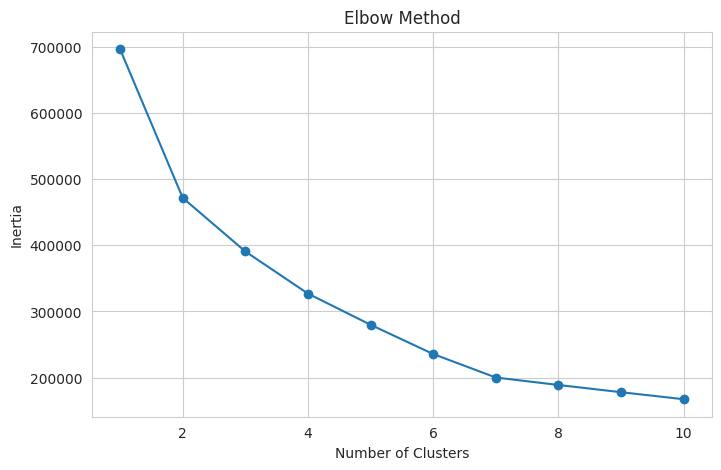

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(1, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), inertia, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

K means Cluster selection - 5- 0.33 , 6 = 0.33 and 4 = 0.35***

In [ ]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

df["cluster"] = clusters

In [ ]:
from sklearn.metrics import silhouette_score

score = silhouette_score(
    X_scaled,
    clusters
)

print(score)

0.3571634183487376


Final Model - K means Segmeentation

In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df["cluster"] = kmeans.fit_predict(X_scaled)

df["cluster"].value_counts()

,count
cluster,
1,59998
0,18582
3,14314
2,6547


In [ ]:
cluster_summary = (
    df.groupby("cluster")[
        [
            "recency_days",
            "total_spend",
            "avg_installments",
            "review_score",
            "return_flag",
            "total_refund_amount",
            "refund_to_spend_ratio"
        ]
    ]
    .mean()
    .round(2)
)

cluster_summary

,recency_days,total_spend,avg_installments,review_score,return_flag,total_refund_amount,refund_to_spend_ratio
cluster,,,,,,,
0,294.51,135.93,2.29,1.83,0.0,0.02,0.00
1,284.00,115.40,1.90,4.75,0.0,0.00,0.00
2,290.37,173.87,2.90,4.10,1.0,136.99,0.87
3,311.01,378.70,8.01,4.26,0.0,0.13,0.00


In [ ]:
cluster_sizes = (
    df["cluster"]
    .value_counts()
    .sort_index()
)

cluster_sizes

,count
cluster,
0,18582
1,59998
2,6547
3,14314


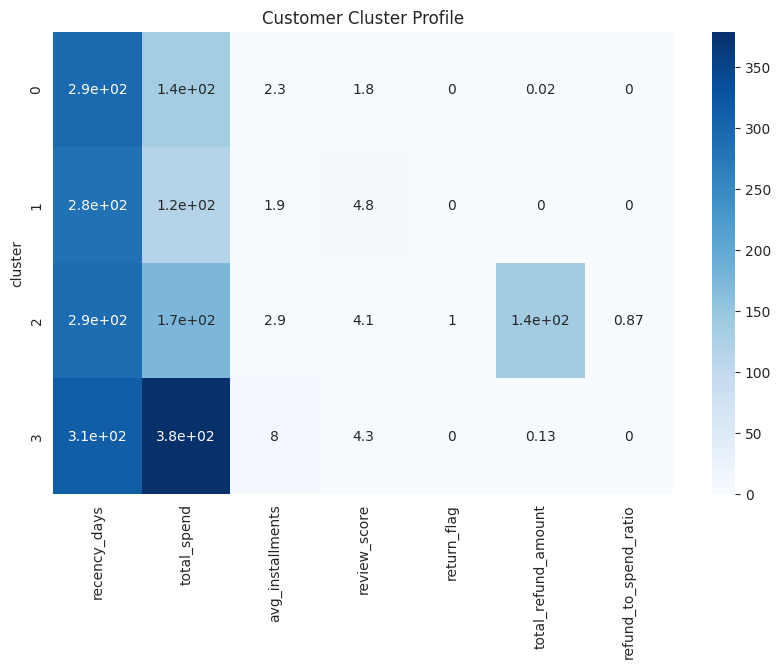

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.heatmap(
    cluster_summary,
    annot=True,
    cmap="Blues"
)

plt.title("Customer Cluster Profile")
plt.show()

In [ ]:
cluster_names = {
    0: "Dissatisfied Standard",
    1: "Satisfied Low-Spend",
    2: "High-Return",
    3: "High-Value Instalment"
}

df["cluster_name"] = df["cluster"].map(cluster_names)

In [ ]:
df.to_csv(
    "/content/drive/MyDrive/Fetch SQL Files/customer_segments_final.csv",
    index=False
)

Visualisation of segments.

/tmp/ipykernel_1983/3737209272.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


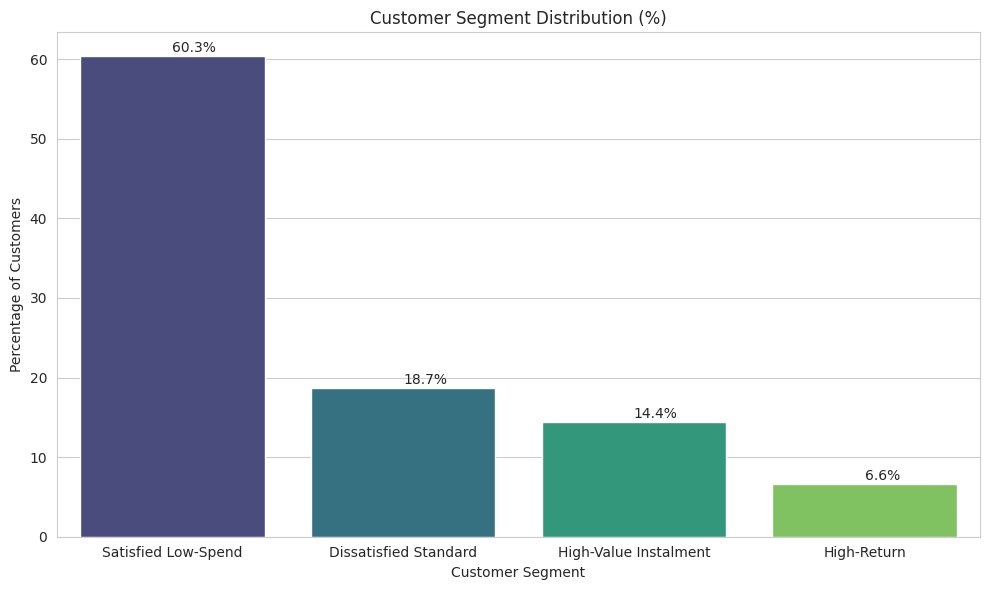

In [ ]:
segment_pct = (
    df["cluster_name"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=segment_pct.index,
    y=segment_pct.values,
    palette="viridis"
)

plt.title("Customer Segment Distribution (%)")
plt.xlabel("Customer Segment")
plt.ylabel("Percentage of Customers")

for i, v in enumerate(segment_pct.values):
    plt.text(i, v + 0.5, f"{v:.1f}%")

plt.tight_layout()
plt.show()